In [4]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
root = Path.cwd().parents[1]
sys.path.extend([str(root), str(root / 'plotting')])

from im_net import datamanager
import datareader

%load_ext autoreload
%autoreload 2

In [2]:
plot_path = "../figures/appendix/ablation"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

## Ablation Study

Memory capacity $\alpha_c$ for a sequence of conditions that progressively add
features toward the full infomorphic network. The baseline ('ablated') uses
stochastic testing; all other conditions use deterministic testing.

**Training commands:**
```bash
python src/training.py +mods/capacity=basic +mods/ablation=full
python src/training.py +mods/capacity=basic +mods/ablation=full ~mods=sgd
python src/training.py +mods/capacity=basic +mods/ablation=full ~mods=sgd model.layer1.freeze_external=True
python src/training.py +mods/capacity=basic binning=adaptive
python src/training.py +mods/capacity=basic binning=adaptive +mods=sgd
```

In [3]:
def find_last_above_threshold(alpha, scores, threshold=0.95):
    """Return last alpha value where score >= threshold for each run. Returns 0 if never reached."""
    result = np.full(alpha.shape[0], 0)
    for i in range(alpha.shape[0]):
        indices = np.where(scores[i] >= threshold)[0]
        if len(indices) > 0:
            result[i] = alpha[i, indices[-1]]
    return result


def readout_score(file):
    """Load m_max (deterministic capacity) from an experiment folder."""
    dm = datamanager.DataManager(file, mode='analysis', add_run_properties=True, verbose=0)
    print(f"Using {dm.all.shape[0]} file(s).")
    return np.array(dm.sel['m_max'])


def readout_stochastic(file):
    """Load stochastic capacity (last alpha above threshold) from an experiment folder."""
    _, patterns, acc_stochastic = datareader.quick_load(
        file, 'capacity', 'patterns', 'capacity', 'acc_stochastic')
    return find_last_above_threshold(patterns, acc_stochastic)


def readout_conditions(file):
    """Return a DataFrame of key configuration parameters for an experiment folder."""
    dm = datamanager.DataManager(file, mode='analysis', add_run_properties=True, verbose=0)
    return dm.sel[['m_max', 'optim_params.name', 'binning.name',
                   'model.init.external_scale', 'model.layer1.freeze_external',
                   'model.layer1.gamma']]


# Profiles defining each ablation condition
_PROFILES = {
    "+determ. testing": {
        "optim_params.name":           "torch.optim.SGD",
        "binning.name":                "im_net.prob_estim.BinningAdaptiveSize",
        "model.init.external_scale":   1.0,
        "model.layer1.freeze_external": False,
    },
    r"+frozen $|\boldsymbol{w}_T|$": {
        "optim_params.name":           "torch.optim.SGD",
        "binning.name":                "im_net.prob_estim.BinningAdaptiveSize",
        "model.init.external_scale":   1.0,
        "model.layer1.freeze_external": True,
    },
    r"+scale $|\boldsymbol{w}_T|=2.3$": {
        "optim_params.name":           "torch.optim.SGD",
        "binning.name":                "im_net.prob_estim.BinningAdaptiveSize",
        "model.init.external_scale":   2.3,
        "model.layer1.freeze_external": True,
    },
    "+optimizer Adam": {
        "optim_params.name":           "torch.optim.Adam",
        "binning.name":                "im_net.prob_estim.BinningAdaptiveSize",
        "model.init.external_scale":   2.3,
        "model.layer1.freeze_external": True,
    },
    "+soft binning": {
        "optim_params.name":           "torch.optim.Adam",
        "binning.name":                "im_net.prob_estim.BinningDifferentiableMarginal",
        "model.init.external_scale":   2.3,
        "model.layer1.freeze_external": True,
        "model.layer1.gamma":          [0, 0, 1, 0, 0],
    },
    "+optimized goal": {
        "optim_params.name":           "torch.optim.Adam",
        "binning.name":                "im_net.prob_estim.BinningDifferentiableMarginal",
        "model.init.external_scale":   2.3,
        "model.layer1.freeze_external": True,
        "model.layer1.gamma":          [0.48, -0.16, 0.25, 0.04, -0.63],
    },
}


def _matches_profile(config: pd.Series, profile: dict) -> bool:
    for key, expected in profile.items():
        if key not in config:
            return False
        actual = config[key]
        if isinstance(expected, float):
            if abs(actual - expected) >= 1e-9:
                return False
        elif actual != expected:
            return False
    return True


def match_profile(df: pd.DataFrame) -> str:
    """Return the condition name for the given single-row conditions DataFrame."""
    config = df.iloc[0] if isinstance(df, pd.DataFrame) else df
    for name, profile in _PROFILES.items():
        if _matches_profile(config, profile):
            return name
    return "UNKNOWN_PROFILE"

## Data Loading

In [ ]:
# TODO: set paths to ablation condition experiment folders (one per condition, in order)
files = [
    '',  # +determ. testing
    '',  # +frozen |w_T|
    '',         # +scale |w_T|=2.3
    '',         # +optimizer Adam
    '',  # +soft binning
    '',  # +optimized goal
]

# TODO: set path to ablated baseline (stochastic test)
file_test = ''

# Load ablation conditions and their capacities
conditions = [match_profile(readout_conditions(f)) for f in files]
alpha      = [readout_score(f) / 100 for f in files]

# Load stochastic baseline
_, x, y = datareader.quick_load(file_test, 'capacity', 'patterns', 'capacity', 'acc_stochastic')
alpha_0  = find_last_above_threshold(x, y) / 100

# Combine baseline + ablation conditions
conditions_composed = ['ablated'] + conditions
mean = [alpha_0.mean()] + [np.array(a).mean() for a in alpha]
std  = [alpha_0.std()]  + [np.array(a).std()  for a in alpha]

print(f"Conditions: {conditions_composed}")
print(f"Mean α_c:   {[f'{m:.2f}' for m in mean]}")

Using 20 file(s).
Using 20 file(s).
Using 20 file(s).
Using 20 file(s).
Using 20 file(s).
Using 20 file(s).
Conditions: ['ablated', '+determ. testing', '+frozen $|\\boldsymbol{w}_T|$', '+scale $|\\boldsymbol{w}_T|=2.3$', '+optimizer Adam', '+soft binning', '+optimized goal']
Mean α_c:   ['0.40', '0.89', '0.92', '1.35', '1.65', '1.60', '1.69']


## Figure: Ablation Bar Chart

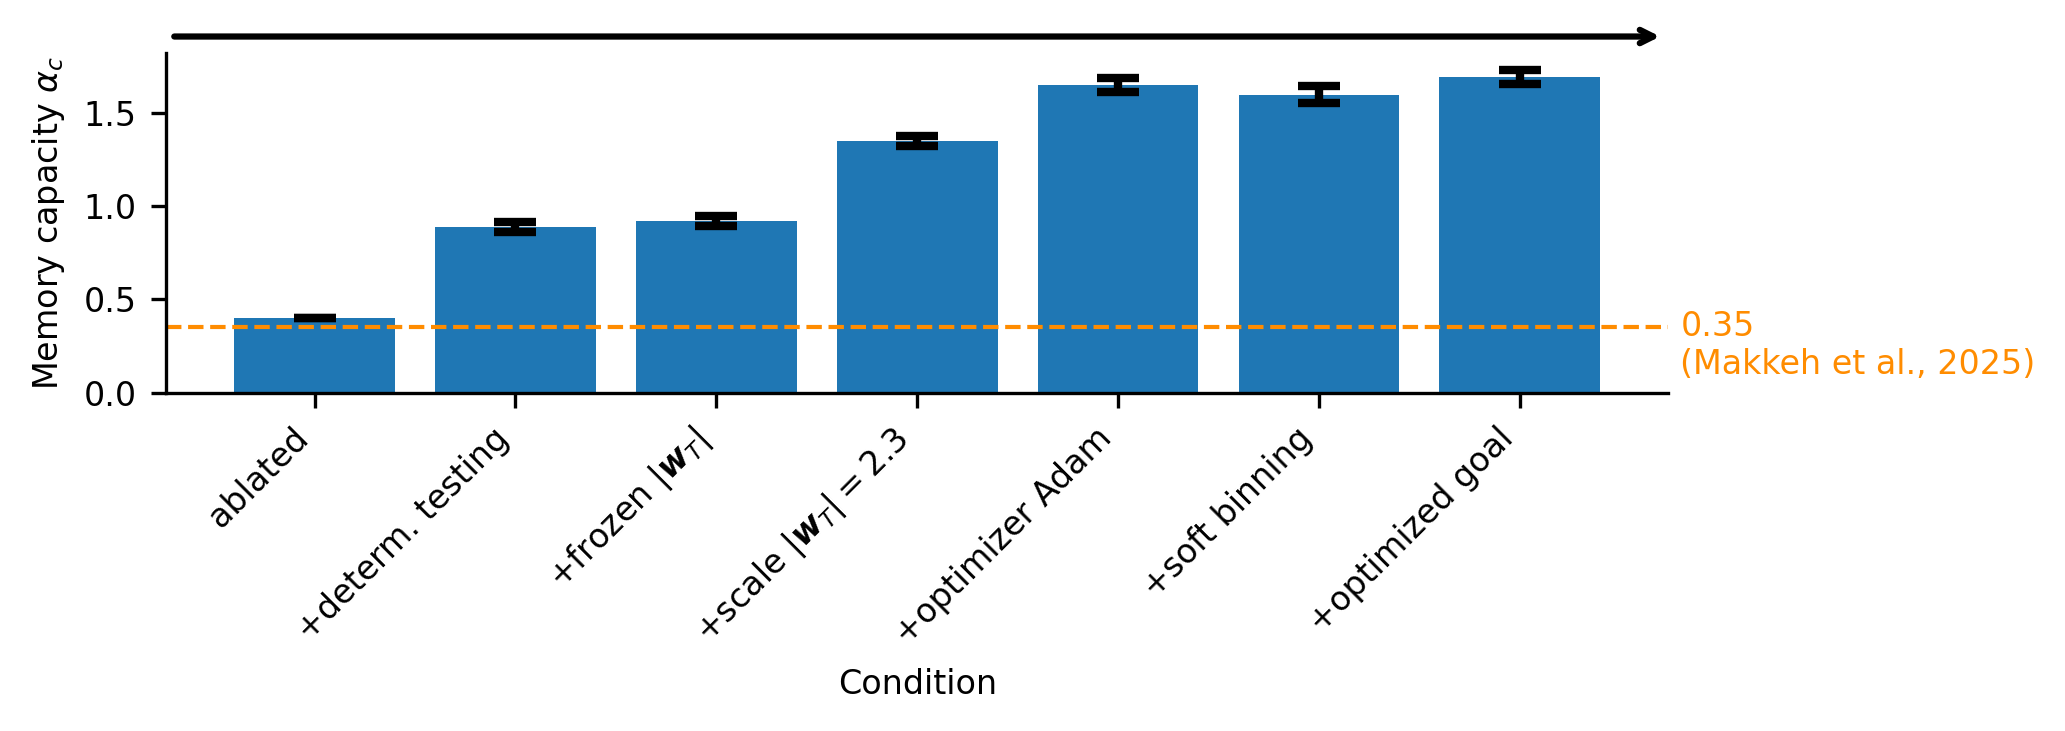

In [32]:
fig, ax = plt.subplots(1, figsize=(7, 2.5))
ax.set_ylabel(r'Memory capacity $\alpha_c$')
ax.set_xlabel('Condition')

ax.bar(conditions_composed, mean)
ax.errorbar(np.arange(len(conditions_composed)), mean, yerr=std,
            fmt='none', ecolor='black', capsize=5, elinewidth=2, capthick=2)

ax.annotate('', xy=(1, 1.05), xytext=(0, 1.05), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')

ax.axhline(0.35, linestyle='--', color='darkorange', linewidth=1)
ax.text(6.8, 0.14, '0.35' + '\n' + '(Makkeh et al., 2025)', ha='left', va='center', color='darkorange', transform=ax.get_xaxis_transform())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# fig.savefig(f"{plot_path}/ablation.svg", bbox_inches='tight')
plt.show()